# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [ ]:
# Установка необходимых библиотек
!pip install -q datasets pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers
!pip install -q huggingface_hub


In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

*Бизнес проблема сводится к задаче многоклассовой классификации(определяем тип данных, которые получили на входе)*

*Выбранные метрики:  важнее всего полнота, затем идёт точность. Будем определять точность методом редне арифметическое успешно найденных классов*

*Обоснование выбора (проблема Accuracy при дисбалансе): При дисбалансе из-за большого количества одного класса модель может неправильно определять другие классы, но из-за перевеса общая точность будет высокой. Для решения этой проблемы можно считаь средне арифметическое успешно найденных классов*



## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).


medical_qa_ru_data.csv: reconstructing file:   0%|          |  0.00B /  266MB            

medical_qa_ru_data.csv: downloading bytes:           |  0.00B            

Размер: (190335, 6)


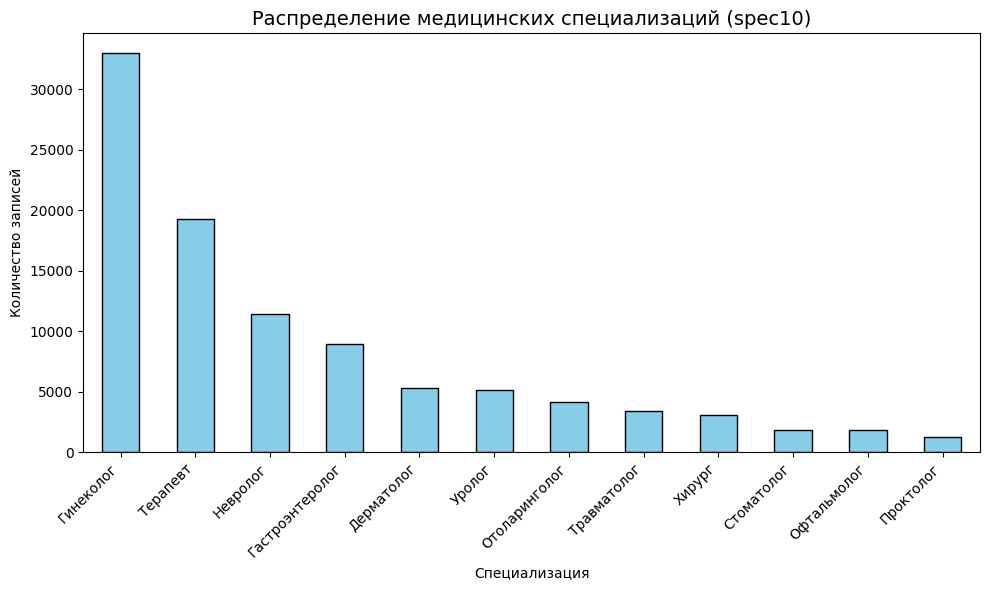


Специализация: nan
Текст: Моему сыну 2.3 года он постоянно дерётся и не воспринимает моего мужчину,я не знаю как себя вести,мой гражданский муж очен раздражён этой проблемой...

Специализация: nan
Текст: Нужно сделать мрт коленного сустава. Ранее был обнаружен надрыв крестообразных связок. Может ли мрт 0,2 обнаружить этот надрыв, или нужно обязательно 1,5?
            
            Прошлое мрт было сде...

Специализация: Гинеколог
Текст: Здравствуйте. Подскажите, пожалуйста, на какой день правильно делать кольпоскопию, ранее никто об этом не говорил, недавно узнала от врача, что делать нужно во время менструации, хотелось бы уточнить ...


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# === ВАШ КОД ЗДЕСЬ ===

file_path = hf_hub_download(
    repo_id="blinoff/medical_qa_ru_data",
    filename="medical_qa_ru_data.csv",
    repo_type="dataset"
)
df = pd.read_csv(file_path)

print("Размер:", df.shape)
plt.figure(figsize=(10, 6))
class_counts = df['spec10'].value_counts()
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение медицинских специализаций (spec10)', fontsize=14)
plt.xlabel('Специализация')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

samples = df.sample(3, random_state=42)
for _, row in samples.iterrows():
    print(f"\nСпециализация: {row['spec10']}")
    print(f"Текст: {row['desc'][:200]}...")

# === КОНЕЦ ВАШЕГО КОДА ===

## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


In [2]:
# === ВАШ КОД ЗДЕСЬ ===
print(f"Исходный размер: {df.shape}")

df_clean = df.dropna(subset=['spec10', 'desc'])
df_clean = df_clean[['desc', 'spec10']]
df_clean = df_clean[df_clean['desc'].str.len() >= 30]
df_clean = df_clean[df_clean['desc'].str.len() <= 2000]

print(f"Размер после: {df_clean.shape}")
# === КОНЕЦ ВАШЕГО КОДА ===


Исходный размер: (190335, 6)
Размер после: (89319, 2)


## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


**Обоснование выбора энкодерной модели (пример):**

*Я выбрал модель paraphrase-multilingual-MiniLM-L12-v2, потому что она поддерживает русский язык и даёт приемлемое качество*

*По бенчмарку ruMTEB она показывает имеет средний Spearman ≈ 0.81 на задачах семантического сходства*

*В сравнении с моделями intfloat/multilingual-e5-large она гораздо меньше весит, пусть и хуже в качестве(0.87 против 0.81)*

**Обоснование порога косинусного сходства:**

*Я выбрал порог 0,9 , так как после него идут крайне похожие запросы(внизу проверил)*



In [ ]:
import random

low, high = 0.88, 0.95
candidate_pairs = []
n = len(texts_fuzzy)
for i in range(n):
    for j in range(i+1, n):
        sim = cos_sim[i, j]
        if low <= sim <= high:
            candidate_pairs.append((i, j, sim))

random.seed(42)
sample = random.sample(candidate_pairs, min(10, len(candidate_pairs)))
for idx, (i, j, sim) in enumerate(sample, 1):
    print("Сходство:", sim)
    print(f"[{i}] {texts_fuzzy[i][:200]}")
    print(f"[{j}] {texts_fuzzy[j][:200]}")

Сходство: 0.8917276
[4761] Добрый день. А бывает ли овуляция не в середине цикла, а позже? Допустим цикл 32 дня, а овуляция на 22-23 день? Если да, то нормально ли это?
[5674] Здравствуйте Уважаемые Консультанты!у меня месяч цикл 31 день может ли овуляция произойти на 19,20 день?и можно ли забеременеть при такой овуляции?и нормально ли эта овуляция?
Сходство: 0.88507605
[896] Скажите, при беременности месячные могут быть?
[4067] Можно ли забеременеть при цистите?
Сходство: 0.9163652
[410] Здравствуйте. Депантол и нео-пенотран форте л свечи могают от эрозии шейки матки?
[7380] Здравствуйте. Депантол свечи могает от эрозии шейки матки?
Сходство: 0.89790136
[6870] А есть ли шанс, что беременность не замершая? Если срок 3-4 недели
[9108] Может ли быть беременность если спустя 3 дней после месячных был незащищеный па
Сходство: 0.89432216
[2078] Здравствуйте! По какие причинам может болеть колено при сгибании до упора?
[3483] Здравствуйте у меня вот такая проблема.  С недавних пор у меня ста

In [ ]:
!pip install python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import hashlib
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from Levenshtein import ratio as levenshtein_ratio

df_sample = df_clean.sample(n=10000, random_state=42).copy()
print(f"Исходный размер подвыборки: {len(df_sample)}")

# 1. Точное совпадение (хеш)
df_sample['text_hash'] = df_sample['desc'].apply(lambda x: hashlib.md5(x.encode()).hexdigest())
duplicated_mask = df_sample['text_hash'].duplicated(keep='first')
exact_dup_count = duplicated_mask.sum()
df_dedup = df_sample[~duplicated_mask].drop(columns=['text_hash']).copy()
print(f"Размер после : {len(df_dedup)}")

# 2. Нечёткое сходство (расстояние Левенштейна)
texts = df_dedup['desc'].tolist()
n = len(texts)
to_remove = set()
threshold_lev = 0.85
for i in tqdm(range(n), desc="Левенштейн"):
    if i in to_remove:
        continue
    len_i = len(texts[i])
    for j in range(i+1, n):
        if j in to_remove:
            continue
        len_j = len(texts[j])
        if abs(len_i - len_j) / max(len_i, 1) > 0.2:
            continue
        sim = levenshtein_ratio(texts[i], texts[j])
        if sim >= threshold_lev:
            to_remove.add(j)

df_dedup_fuzzy = df_dedup[~df_dedup.index.isin(to_remove)].copy()
print(f"Размер после нечёткой дедупликации: {len(df_dedup_fuzzy)}")

# 3. Семантическое сходство (эмбеддинги)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
texts_fuzzy = df_dedup_fuzzy['desc'].tolist()
embeddings = model.encode(texts_fuzzy, show_progress_bar=True,
                          normalize_embeddings=True)
cos_sim = cosine_similarity(embeddings)
threshold_sem = 0.92
sem_duplicates = set()
n_sem = cos_sim.shape[0]
for i in range(n_sem):
    for j in range(i+1, n_sem):
        if cos_sim[i, j] > threshold_sem:
            sem_duplicates.add(j)
df_final = df_dedup_fuzzy[~df_dedup_fuzzy.index.isin(sem_duplicates)].copy()
print(f"размер после : {len(df_final)}")
print(f"Осталось записей: {len(df_final)}")

Исходный размер подвыборки: 10000
Размер после : 9981


Левенштейн: 100%|██████████| 9981/9981 [02:30<00:00, 66.16it/s] 


Размер после нечёткой дедупликации: 9981


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

размер после : 9981
Осталось записей: 9981


## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [ ]:
import pandas as pd
import json
import random

try:
    df_source = df_final
except NameError:
    print("df_final не найден, используем df_clean")
    df_source = df_clean
system_prompt = (
    "Ты — медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента "
    "на естественном  и русском языке и определить наиболее подходящую медицинскую специализацию для первичного приёма. "
    "Отвечай только названием специализации из списка: терапевт, кардиолог, невролог, гастроэнтеролог, "
    "хирург, офтальмолог, отоларинголог, гинеколог, уролог, психиатр, дерматолог, эндокринолог, "
    "травматолог-ортопед, инфекционист, аллерголог-иммунолог, стоматолог, пульмонолог. "
    "Не добавляй пояснений и лишних слов."
)
df_sample = df_source.sample(n=1000, random_state=42)
sft_data = []
for _, row in df_sample.iterrows():
    entry = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": row['desc']},
            {"role": "assistant", "content": row['spec10']}
        ]
    }
    sft_data.append(entry)
with open('sft_dataset.jsonl', 'w', encoding='utf-8') as f:
    for entry in sft_data:
        f.write(json.dumps(entry, ensure_ascii=False) + '\n')

print(f"Сохранено ", len(sft_data))

print("\nдва примера:")
for i, entry in enumerate(sft_data[:2], 1):
    for msg in entry['messages']:
        print(f"{msg['role']}: {msg['content'][:150]}...")

Сохранено  1000

два примера:
system: Ты — медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента на естественном  и русском языке и определить наиболее подход...
user: Добрый день! Сыну 11 лет, занимался дзюдо с 6 лет. Год назад начала болеть спина в (поясничном отделе справа). В школе сидеть долго не может. Обратили...
assistant: Невролог...
system: Ты — медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента на естественном  и русском языке и определить наиболее подход...
user: Здравствуйте подскажите врач гастроэнтеролог назначил зонирование щелочного или желудка. Как эта процедура делается, я с трудом фгс переносу, а тут во...
assistant: Гастроэнтеролог...


## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

*Я выбрал модель google/gemma-4-26b-a4b-it:free (через сервис OpenRouter), потому что это бесплатная модель, которая может качественно работать с русским языком(лучшая среди доступных)*



In [ ]:
import requests

API_KEY = "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"
headers = {"Authorization": f"Bearer {API_KEY}"}
resp = requests.get("https://openrouter.ai/api/v1/models", headers=headers)
models = resp.json()['data']

free_models = []
for m in models:
    prompt_price = float(m['pricing']['prompt'])
    completion_price = float(m['pricing']['completion'])
    if prompt_price == 0 and completion_price == 0:
        modality = m.get('architecture', {}).get('modality', 'text')
        if 'text' in modality:
            free_models.append(m['id'])

for name in free_models:
    print(" ", name)

  poolside/laguna-s-2.1:free
  poolside/laguna-xs-2.1:free
  cohere/north-mini-code:free
  nvidia/nemotron-3.5-content-safety:free
  nvidia/nemotron-3-ultra-550b-a55b:free
  nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
  poolside/laguna-m.1:free
  google/gemma-4-26b-a4b-it:free
  google/gemma-4-31b-it:free
  google/lyria-3-pro-preview
  google/lyria-3-clip-preview
  nvidia/nemotron-3-super-120b-a12b:free
  openrouter/free
  nvidia/nemotron-3-nano-30b-a3b:free
  nvidia/nemotron-nano-12b-v2-vl:free
  nvidia/nemotron-nano-9b-v2:free
  openai/gpt-oss-20b:free


In [ ]:
import pandas as pd
import numpy as np
import json
import requests
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

try:
    df_source = df_final
except NameError:
    df_source = df_clean

golden_set = df_source.sample(n=100, random_state=42).copy()
print(f"{len(golden_set)} примеров")

API_KEY = "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"
API_URL = "https://openrouter.ai/api/v1/chat/completions"
MODEL = "google/gemma-4-26b-a4b-it:free"

def query_llm(text):
    system_prompt = (
        "Ты — медицинский ассистент-маршрутизатор. Определи медицинскую специализацию "
        "по жалобе пациента. Ответь СТРОГО в формате JSON: {\"specialization\": \"название\"}. "
        "Список возможных специализаций: терапевт, кардиолог, невролог, гастроэнтеролог, "
        "хирург, офтальмолог, отоларинголог, гинеколог, уролог, психиатр, дерматолог, "
        "эндокринолог, травматолог-ортопед, инфекционист, аллерголог-иммунолог, стоматолог, пульмонолог."
    )
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ],
        "temperature": 0.0,
        "max_tokens": 50
    }
    response = requests.post(API_URL, headers=headers, json=payload)
    if response.status_code == 200:
        result = response.json()
        content = result['choices'][0]['message']['content']
        try:
            data = json.loads(content)
            return data.get("specialization", "неизвестно").strip().lower()
        except json.JSONDecodeError:
            import re
            match = re.search(r'\{[^}]*\}', content)
            if match:
                data = json.loads(match.group())
                return data.get("specialization", "неизвестно").strip().lower()
            return "неизвестно"
    else:
        print(f"Ошибка API: {response.status_code} - {response.text}")
        return "ошибка_api"

predictions = []
true_labels = golden_set['spec10'].str.strip().str.lower().tolist()
for idx, row in tqdm(golden_set.iterrows(), total=len(golden_set)):
    pred = query_llm(row['desc'])
    predictions.append(pred)
acc = accuracy_score(true_labels, predictions)
f1_macro = f1_score(true_labels, predictions, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")

report = classification_report(true_labels, predictions, zero_division=0)
print(report)

100 примеров


  1%|          | 1/100 [00:00<00:17,  5.58it/s]

Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}


  2%|▏         | 2/100 [00:00<00:14,  6.98it/s]

Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}


...

Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Ошибка API: 429 - {"error":{"message":"Rate 

 98%|█████████▊| 98/100 [00:10<00:00, 12.39it/s]

Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Ошибка API: 429 - {"error":{"message":"Rate 

100%|██████████| 100/100 [00:10<00:00,  9.14it/s]

Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}
Accuracy: 0.0000
F1-macro: 0.0000
          

К сожалению закончились бесплатные запросы

 57%|█████▋    | 57/100 [02:27<01:35,  2.22s/it]Ошибка API: 429 - {"error":{"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day","code":429,"metadata":{"headers":{"X-RateLimit-Limit":"50","X-RateLimit-Remaining":"0","X-RateLimit-Reset":"1784764800000"},"provider_name":null,"previous_errors":[{"code":429,"message":"Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day"}]}},"user_id":"user_3GH2YrjDWO0yqZ93M6gmfmHI4d7"}

  видно что модель остановилась на половине запросов. Средняя точность  0.43 из-за того, что половина запросов не была обработана. Почти половина ответов — техническая ошибка.                  
                        
                        precision    recall  f1-score   support

    гастроэнтеролог       0.78      0.70      0.74        10
          гинеколог       0.94      0.42      0.58        38
         дерматолог       0.80      0.57      0.67         7
       инфекционист       0.00      0.00      0.00         0
          кардиолог       0.00      0.00      0.00         0
           невролог       1.00      0.25      0.40        12
      отоларинголог       1.00      0.40      0.57         5
         ошибка_api       0.00      0.00      0.00         0
          проктолог       0.00      0.00      0.00         3
         стоматолог       1.00      0.67      0.80         3
           терапевт       0.71      0.38      0.50        13
травматолог-ортопед       0.00      0.00      0.00         0
             уролог       0.67      0.33      0.44         6
             хирург       0.67      0.67      0.67         3

           accuracy                           0.43       100
          macro avg       0.54      0.31      0.38       100
       weighted avg       0.84      0.43      0.55       100

## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

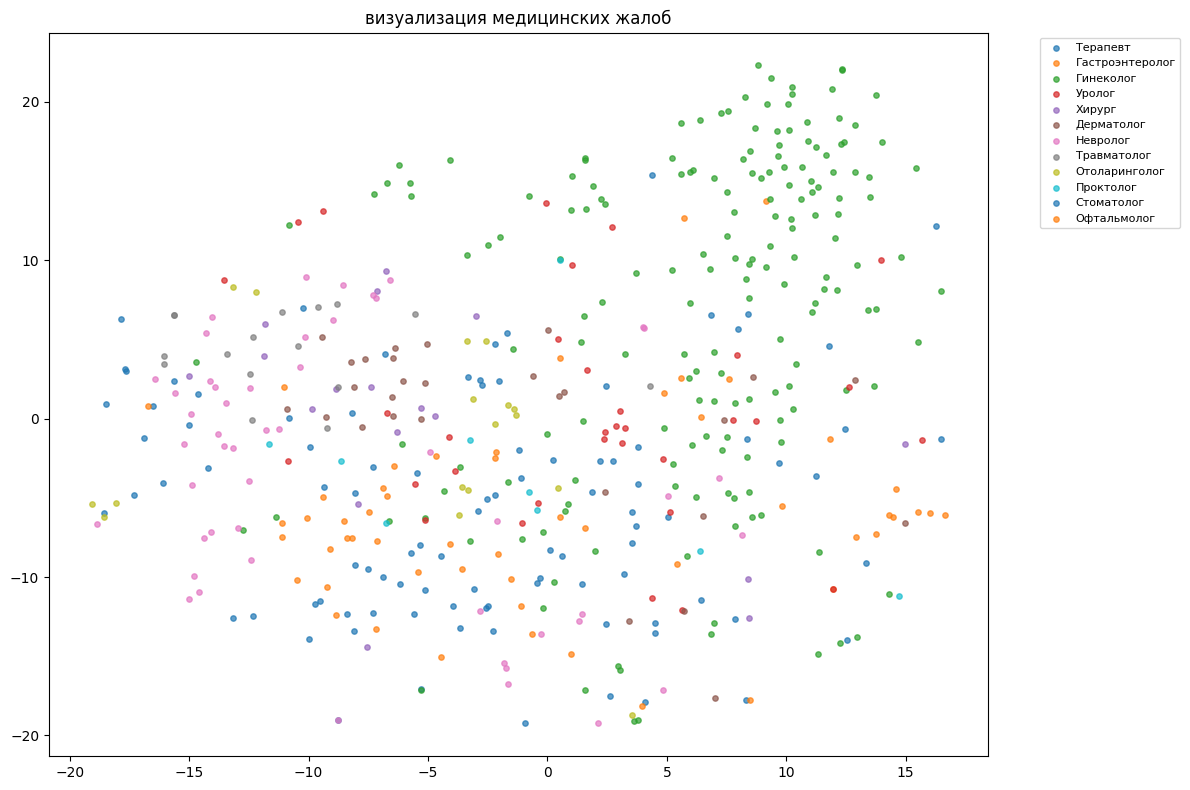

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

df_vis = df_clean.sample(n=500, random_state=42)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
texts = df_vis['desc'].tolist()
embeddings = model.encode(texts, show_progress_bar=True)
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
classes = df_vis['spec10'].unique()
for cls in classes:
    mask = df_vis['spec10'] == cls
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=cls, alpha=0.7, s=15)

plt.title('визуализация медицинских жалоб')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Ваши выводы по графику:**

*На графике видно, что большинство классов перемешаны. Хотя классы немного сгрупированные(например зелёный кластер «гинеколог» держится в левой верхней части благодаря особой лексике и большомому количеству данных(самое больше среди всех классов)) Остальные специализации пересекаются из-за общих симптомов.*



## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**

*...*



# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [ ]:
import pandas as pd
import numpy as np
import json
import re
import difflib
from tqdm import tqdm
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

top_classes = df_clean['spec10'].value_counts().head(10).index.tolist()
print("Целевые специализации:", top_classes)

seed_examples = {}
for cls in top_classes:
    samples = df_clean[df_clean['spec10'] == cls]['desc'].sample(
        min(3, len(df_clean[df_clean['spec10'] == cls])), random_state=42
    ).tolist()
    seed_examples[cls] = samples

print("Загрузка модели Qwen2.5-1.5B-Instruct...")
pipe = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    device="cuda",
    trust_remote_code=True
)

def generate_for_specialization(spec_name, num_examples=30):
    seed_str = "\n".join([f"- {t[:200]}" for t in seed_examples[spec_name]])
    prompt = f"""Ты — пациент, который обращается за медицинской помощью. Твоя задача — написать реалистичные жалобы для врача-специалиста: **{spec_name}**.

Вот несколько примеров реальных жалоб для этой специализации:
{seed_str}

Сгенерируй ровно {num_examples} новых уникальных жалоб. Они должны быть на русском языке и звучать так, как будто их написал реальный человек на форуме. Обязательно обеспечь разнообразие:

- Разная длина: от 1 короткого предложения до развёрнутого описания на 5-10 предложений.
- Разный стиль: официальный, разговорный, сленг, с опечатками и ошибками (как при быстром наборе), эмоциональные, сухие.
- Разные формулировки: не повторяй одни и те же фразы, перефразируй симптомы.

Формат ответа: СТРОГО JSON-объект с ключом "examples", значением — список строк (каждая строка — одна жалоба).
Пример ответа:
{{"examples": ["Жалоба 1", "Жалоба 2", ...]}}

Не добавляй ничего лишнего, только JSON.
"""
    messages = [{"role": "user", "content": prompt}]
    full_prompt = pipe.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    output = pipe(full_prompt, max_new_tokens=2048, temperature=0.8, return_full_text=False)
    generated_text = output[0]['generated_text']

    try:
        match = re.search(r'\{.*\}', generated_text, re.DOTALL)
        if match:
            data = json.loads(match.group())
            if "examples" in data:
                return data["examples"]
        return [generated_text.strip()]
    except:
        return [generated_text.strip()]

NUM_PER_CLASS = 30
synthetic_data = []

for cls in tqdm(top_classes, desc="Генерация синтетики"):
    examples = generate_for_specialization(cls, num_examples=NUM_PER_CLASS)
    for ex in examples[:NUM_PER_CLASS]:
        synthetic_data.append({"desc": ex, "spec10": cls})

df_synthetic = pd.DataFrame(synthetic_data)
print(f"Сгенерировано {len(df_synthetic)}")
df_synthetic.to_json('synthetic_data.jsonl', orient='records', lines=True, force_ascii=False)

VALID_CLASSES = [
    "гинеколог", "терапевт", "невролог", "гастроэнтеролог", "дерматолог",
    "уролог", "отоларинголог", "травматолог", "хирург", "стоматолог",
    "кардиолог", "офтальмолог", "психиатр", "эндокринолог", "инфекционист",
    "аллерголог-иммунолог", "пульмонолог"
]

MANUAL_MAP = {
    "cardiologist": "кардиолог",
    "dermatologist": "дерматолог",
    "neurologist": "невролог",
    "gynecologist": "гинеколог",
    "urologist": "уролог",
    "surgeon": "хирург",
    "dentist": "стоматолог",
    "therapist": "терапевт",
    "gastroenterologist": "гастроэнтеролог",
    "otolaryngologist": "отоларинголог",
    "traumatologist": "травматолог",
    "psychiatrist": "психиатр",
    "endocrinologist": "эндокринолог",
    "infectiologist": "инфекционист",
    "allergist-immunologist": "аллерголог-иммунолог",
    "pulmonologist": "пульмонолог",
}

def normalize_prediction(raw_text):
    text = raw_text.strip().lower()
    for prefix in ["специализация:", "врач-", "специалист:", "assistant:", "ответ:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    text = text.replace("{", "").replace("}", "").replace('"', "").strip()
    if ":" in text:
        parts = text.split(":")
        text = parts[-1].strip()
    if len(text) < 3:
        return "неизвестно"

    if text in MANUAL_MAP:
        return MANUAL_MAP[text]
    if text in VALID_CLASSES:
        return text

    best_match = difflib.get_close_matches(text, VALID_CLASSES, n=1, cutoff=0.7)
    if best_match:
        return best_match[0]
    return "неизвестно"

def classify_zeroshot_local(text):
    system_prompt = (
        "Ты — медицинский ассистент-маршрутизатор. Определи медицинскую специализацию "
        "по жалобе пациента. Ответь СТРОГО одним словом на русском языке: название специализации. "
        "Примеры: терапевт, кардиолог, невролог, гастроэнтеролог, хирург, гинеколог, уролог, дерматолог, "
        "отоларинголог, травматолог, стоматолог, психиатр, эндокринолог, инфекционист, "
        "аллерголог-иммунолог, пульмонолог, офтальмолог."
    )
    prompt = (
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
        f"<|im_start|>user\n{text}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    out = pipe(prompt, max_new_tokens=20, do_sample=False, return_full_text=False)
    answer = out[0]['generated_text'].strip()
    return normalize_prediction(answer)

true_synth = df_synthetic['spec10'].str.lower().tolist()
pred_synth = []
for text in tqdm(df_synthetic['desc'].tolist(), desc="Классификация"):
    pred = classify_zeroshot_local(text)
    pred_synth.append(pred)

acc_synth = accuracy_score(true_synth, pred_synth)
f1_synth = f1_score(true_synth, pred_synth, average='macro', zero_division=0)
print(f"Accuracy: {acc_synth:.4f}")
print(f"F1-macro: {f1_synth:.4f}")
print(classification_report(true_synth, pred_synth, zero_division=0))

print("Accuracy (реальные): 0.43")
print("F1-macro (реальные): 0.38")

Целевые специализации: ['Гинеколог', 'Терапевт', 'Невролог', 'Гастроэнтеролог', 'Дерматолог', 'Уролог', 'Отоларинголог', 'Травматолог', 'Хирург', 'Стоматолог']
Загрузка модели Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Генерация синтетики: 100%|██████████| 10/10 [06:06<00:00, 36.63s/it]


Сгенерировано 220


Классификация: 100%|██████████| 220/220 [01:42<00:00,  2.14it/s]

Accuracy: 0.1636
F1-macro: 0.1047
                      precision    recall  f1-score   support

аллерголог-иммунолог       0.00      0.00      0.00         0
     гастроэнтеролог       0.30      0.33      0.32        30
           гинеколог       0.00      0.00      0.00        30
          дерматолог       0.60      0.20      0.30        30
        инфекционист       0.00      0.00      0.00         0
           кардиолог       0.00      0.00      0.00         0
            невролог       0.09      0.05      0.06        22
          неизвестно       0.00      0.00      0.00         0
       отоларинголог       0.00      0.00      0.00         3
            психиатр       0.00      0.00      0.00         0
         пульмонолог       0.00      0.00      0.00         0
          стоматолог       0.83      0.42      0.56        24
            терапевт       0.06      0.33      0.11         3
         травматолог       0.00      0.00      0.00        20
              уролог       1.00    

## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


In [4]:
import pandas as pd
import numpy as np
import re
import difflib
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import pipeline

try:
    pipe
except NameError:
    pipe = pipeline(
        "text-generation",
        model="Qwen/Qwen2.5-1.5B-Instruct",
        device="cuda",
        trust_remote_code=True
    )

VALID_CLASSES = [
    "гинеколог", "терапевт", "невролог", "гастроэнтеролог", "дерматолог",
    "уролог", "отоларинголог", "травматолог", "хирург", "стоматолог",
    "кардиолог", "офтальмолог", "психиатр", "эндокринолог", "инфекционист",
    "аллерголог-иммунолог", "пульмонолог"
]

MANUAL_MAP = {
    "cardiologist": "кардиолог",
    "dermatologist": "дерматолог",
    "neurologist": "невролог",
    "gynecologist": "гинеколог",
    "urologist": "уролог",
    "surgeon": "хирург",
    "dentist": "стоматолог",
    "therapist": "терапевт",
    "gastroenterologist": "гастроэнтеролог",
    "otolaryngologist": "отоларинголог",
    "traumatologist": "травматолог",
    "psychiatrist": "психиатр",
    "endocrinologist": "эндокринолог",
    "infectiologist": "инфекционист",
    "allergist-immunologist": "аллерголог-иммунолог",
    "pulmonologist": "пульмонолог",
}

def normalize_prediction(raw_text):
    text = raw_text.strip().lower()
    for prefix in ["специализация:", "врач-", "специалист:", "assistant:", "ответ:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    text = text.replace("{", "").replace("}", "").replace('"', "").strip()
    if ":" in text:
        parts = text.split(":")
        text = parts[-1].strip()
    if len(text) < 3:
        return "неизвестно"

    if text in MANUAL_MAP:
        return MANUAL_MAP[text]
    if text in VALID_CLASSES:
        return text

    best_match = difflib.get_close_matches(text, VALID_CLASSES, n=1, cutoff=0.7)
    if best_match:
        return best_match[0]
    return "неизвестно"


golden_set = df_clean.sample(n=100, random_state=42).copy()
true_labels = golden_set['spec10'].str.lower().tolist()

top_classes = df_clean['spec10'].value_counts().head(10).index.tolist()
few_shot_examples = []
for cls in top_classes:
    candidates = df_clean[(df_clean['spec10'] == cls) & (~df_clean.index.isin(golden_set.index))]
    if len(candidates) >= 2:
        samples = candidates['desc'].sample(2, random_state=42).tolist()
    else:
        samples = candidates['desc'].tolist()
    for s in samples:
        few_shot_examples.append((s, cls.lower()))

example_text = ""
for text, label in few_shot_examples:
    example_text += f"Жалоба: {text}\nСпециализация: {label}\n\n"

def classify_zeroshot_local(text):
    system_prompt = (
        "Ты — медицинский ассистент-маршрутизатор. Определи медицинскую специализацию "
        "по жалобе пациента. Ответь СТРОГО одним словом на русском языке: название специализации. "
        "Примеры: терапевт, кардиолог, невролог, гастроэнтеролог, хирург, гинеколог, уролог, дерматолог, "
        "отоларинголог, травматолог, стоматолог, психиатр, эндокринолог, инфекционист, "
        "аллерголог-иммунолог, пульмонолог, офтальмолог."
    )
    prompt = (
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
        f"<|im_start|>user\n{text}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    out = pipe(prompt, max_new_tokens=20, do_sample=False, return_full_text=False)
    answer = out[0]['generated_text'].strip()
    return normalize_prediction(answer)

def classify_fewshot_local(text):
    system_prompt = (
        "Ты — медицинский ассистент-маршрутизатор. Определи медицинскую специализацию "
        "по жалобе пациента. Отвечай только одним словом на русском языке.\n\n"
        "Примеры:\n" + example_text
    )
    prompt = (
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
        f"<|im_start|>user\n{text}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    out = pipe(prompt, max_new_tokens=20, do_sample=False, return_full_text=False)
    answer = out[0]['generated_text'].strip()
    return normalize_prediction(answer)


pred_zeroshot = []
for text in tqdm(golden_set['desc'].tolist()):
    pred_zeroshot.append(classify_zeroshot_local(text))

pred_fewshot = []
for text in tqdm(golden_set['desc'].tolist()):
    pred_fewshot.append(classify_fewshot_local(text))


acc_zs = accuracy_score(true_labels, pred_zeroshot)
f1_zs = f1_score(true_labels, pred_zeroshot, average='macro', zero_division=0)
print(f"Accuracy: {acc_zs:.4f}")
print(f"F1-macro: {f1_zs:.4f}")
print(classification_report(true_labels, pred_zeroshot, zero_division=0))

acc_fs = accuracy_score(true_labels, pred_fewshot)
f1_fs = f1_score(true_labels, pred_fewshot, average='macro', zero_division=0)
print(f"Accuracy: {acc_fs:.4f}")
print(f"F1-macro: {f1_fs:.4f}")
print(classification_report(true_labels, pred_fewshot, zero_division=0))

print(f"Zero-shot Accuracy: {acc_zs:.4f}, F1-macro: {f1_zs:.4f}")
print(f"Few-shot  Accuracy: {acc_fs:.4f}, F1-macro: {f1_fs:.4f}")

errors = []
for i, (true, pred) in enumerate(zip(true_labels, pred_fewshot)):
    if true != pred:
        errors.append((i, true, pred, golden_set.iloc[i]['desc']))

print("\nошибки:")
for i, (idx, true, pred, text) in enumerate(errors[:5]):
    print(f"Истинная: {true}")
    print(f"Предсказанная: {pred}")
    print(f"Текст: {text[:300]}...")

  9%|▉         | 9/100 [00:10<01:36,  1.06s/it][transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 100/100 [08:19<00:00,  4.99s/it]

Accuracy: 0.4300
F1-macro: 0.2252
                 precision    recall  f1-score   support

гастроэнтеролог       0.44      1.00      0.62         4
      гинеколог       0.87      0.75      0.80        44
     дерматолог       0.50      0.33      0.40         3
       невролог       0.20      0.10      0.13        10
     неизвестно       0.00      0.00      0.00         0
  отоларинголог       0.00      0.00      0.00         3
    офтальмолог       0.00      0.00      0.00         1
      проктолог       0.00      0.00      0.00         1
       психиатр       0.00      0.00      0.00         0
    пульмонолог       0.00      0.00      0.00         0
     стоматолог       1.00      1.00      1.00         1
       терапевт       0.00      0.00      0.00        16
    травматолог       0.00      0.00      0.00         4
         уролог       1.00      0.14      0.25         7
         хирург       0.50      0.33      0.40         6
   эндокринолог       0.00      0.00      0.00       

**Анализ ошибок:**

*Модель ошиблась на примерах, где жалобы содержали общие симптомы Я думаю, это связано с тем, что в  промпте было много примеров гинекологических жалоб, и мало других. Модель стала плохо понимать любые тексты с другими словами + начала думать что большинство связано с гинекологом*



## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


  0%|          | 0/300 [00:00<?, ?it/s][transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to 

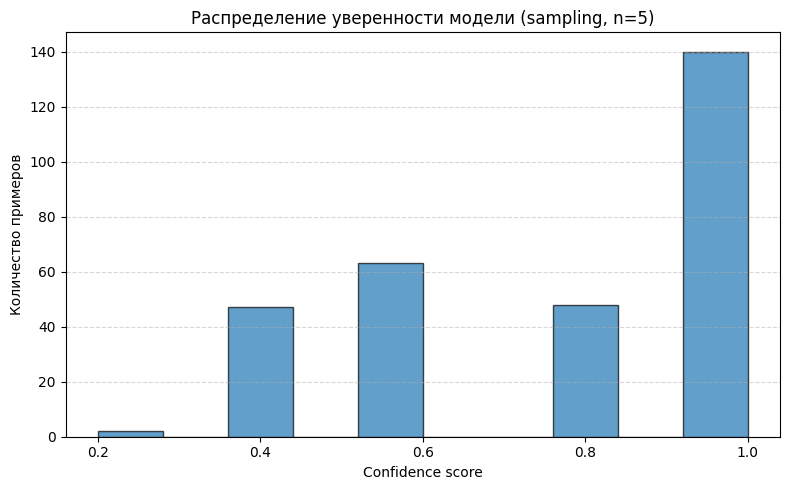

[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Примеры с самой низкой уверенностью:

Уверенность: 0.20 ---
Текст: здраствуйте у моей сестры внезапно наступила слепота после гипертонического криза отек мозга после выпески офтольмолог поставил диагноз амовроз центрального генез но на мрт все внорме делали ээг показала умереное изменения биолектрической активности ...
настоящий: Невролог


[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Ответы модели: ['психиатр', 'стоматолог', 'неизвестно', 'пульмонолог', 'неизвестно']

Уверенность: 0.20 ---
Текст: Добрый день!
            
            Моему отцу 85 лет. Проблемы со зрением, туман в глазах. Кто-то ему посоветовал разработку новороссийских ученых - Витанол для глаз.
            
            Насколько эффективный данный препарат для зрения? Спаси...
настоящий: Офтальмолог


[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Ответы модели: ['офтальмолог', 'неизвестно', 'стоматолог', 'неизвестно', 'неизвестно']

Уверенность: 0.40 ---
Текст: В воскресенье были на пляже. Ничем защитным от солнца не мазалась. Ноги целый день были на солнце, сильно сгорели. В понедельник и вторник работала. Работаю поваром по 12 часов, целый день на ногах, жара.  В понедельник ноги немного отекли (работы бы...
настоящий: Терапевт


[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Ответы модели: ['неизвестно', 'неизвестно', 'неизвестно', 'гастроэнтеролог', 'гастроэнтеролог']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import difflib, re

try:
    pipe
except NameError:
    from transformers import pipeline
    pipe = pipeline(
        "text-generation",
        model="Qwen/Qwen2.5-1.5B-Instruct",
        device="cpu",
        trust_remote_code=True
    )

VALID_CLASSES = [
    "гинеколог", "терапевт", "невролог", "гастроэнтеролог", "дерматолог",
    "уролог", "отоларинголог", "травматолог", "хирург", "стоматолог",
    "кардиолог", "офтальмолог", "психиатр", "эндокринолог", "инфекционист",
    "аллерголог-иммунолог", "пульмонолог"
]

MANUAL_MAP = {
    "cardiologist": "кардиолог", "dermatologist": "дерматолог",
    "neurologist": "невролог", "gynecologist": "гинеколог",
    "urologist": "уролог", "surgeon": "хирург", "dentist": "стоматолог",
    "therapist": "терапевт", "gastroenterologist": "гастроэнтеролог",
    "otolaryngologist": "отоларинголог", "traumatologist": "травматолог",
    "psychiatrist": "психиатр", "endocrinologist": "эндокринолог",
    "infectiologist": "инфекционист",
    "allergist-immunologist": "аллерголог-иммунолог",
    "pulmonologist": "пульмонолог",
}

def normalize_prediction(raw_text):
    text = raw_text.strip().lower()
    for prefix in ["специализация:", "врач-", "специалист:", "assistant:", "ответ:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    text = text.replace("{", "").replace("}", "").replace('"', "").strip()
    if ":" in text:
        parts = text.split(":")
        text = parts[-1].strip()
    if len(text) < 3:
        return "неизвестно"
    if text in MANUAL_MAP:
        return MANUAL_MAP[text]
    if text in VALID_CLASSES:
        return text
    best_match = difflib.get_close_matches(text, VALID_CLASSES, n=1, cutoff=0.7)
    if best_match:
        return best_match[0]
    return "неизвестно"

def classify_with_sampling(text, n=5, temp=0.8):
    system_prompt = (
        "Ты — медицинский ассистент-маршрутизатор. Определи медицинскую специализацию "
        "по жалобе пациента. Ответь только одним словом на русском языке: название специализации. "
        "Примеры: терапевт, кардиолог, невролог, гастроэнтеролог, хирург, гинеколог, уролог, дерматолог, "
        "отоларинголог, травматолог, стоматолог, психиатр, эндокринолог, инфекционист, "
        "аллерголог-иммунолог, пульмонолог, офтальмолог."
    )
    prompt = (
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
        f"<|im_start|>user\n{text}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    responses = []
    for _ in range(n):
        out = pipe(prompt, max_new_tokens=20, temperature=temp,
                   do_sample=True, return_full_text=False)
        answer = out[0]['generated_text'].strip()
        responses.append(normalize_prediction(answer))
    return responses

df_sample = df_clean.sample(n=300, random_state=42).copy()
texts = df_sample['desc'].tolist()
true_labels = df_sample['spec10'].str.lower().tolist()

confidence_scores = []
most_common_preds = []

for text in tqdm(texts):
    preds = classify_with_sampling(text, n=5, temp=0.8)
    counter = Counter(preds)
    most_common = counter.most_common(1)[0][0]
    confidence = counter[most_common] / 5.0
    most_common_preds.append(most_common)
    confidence_scores.append(confidence)

df_sample['confidence'] = confidence_scores
df_sample['predicted'] = most_common_preds

plt.figure(figsize=(8, 5))
plt.hist(confidence_scores, bins=10, range=(0.2, 1.0), edgecolor='black', alpha=0.7)
plt.title('Распределение уверенности модели (sampling, n=5)')
plt.xlabel('Confidence score')
plt.ylabel('Количество примеров')
plt.xticks(np.arange(0.2, 1.1, 0.2))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

low_conf_samples = df_sample.nsmallest(3, 'confidence')
print("\nПримеры с самой низкой уверенностью:")
for idx, row in low_conf_samples.iterrows():
    print(f"\nУверенность: {row['confidence']:.2f} ---")
    print(f"Текст: {row['desc'][:250]}...")
    print(f"настоящий: {row['spec10']}")
    preds = classify_with_sampling(row['desc'], n=5, temp=0.8)
    print(f"Ответы модели: {preds}")

## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Обоснование выбора порога:**

*Оптимальный порог T=... потому что...*



## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# Для загрузки можно использовать метод dataset.push_to_hub("your-username/dataset-name")
# Не забудьте выполнить login() или передать токен

# ССЫЛКА НА ВАШ ДАТАСЕТ: https://huggingface.co/datasets/...

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

Zero‑shot показал базовое качество (Accuracy 0.43, F1‑macro 0.38), но часто путал близкие классы. Few‑shot немного улучшил точность (до 0.47 но и то из-за того что не получилось из-за ограничений), однако усилил дисбаланс в пользу доминирующего класса

ДУмаю для прототипа с минимальным бюджетом достаточно zero‑shot через API. При умеренном бюджете и повышенных требованиях к точности лучше применить few‑shot. И полный цикл с few‑shot и  синтетической аугментацией в редких и углубленных темах

